Set hi-res plotting for nicer inline charts and import the basic libraries we’ll use.

In [1]:
%config InlineBackend.figure_format = 'retina'  # crisp inline figures

import warnings, pathlib, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 180
mpl.rcParams['figure.autolayout'] = True

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    classification_report, roc_curve, confusion_matrix
)

# Optional tree model (only if installed)
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

RNG = 42

Set where the CSVs live and define a helper to read them with optional date parsing.

In [2]:
DATA_DIR = pathlib.Path("Original Data")  

PATHS = {
    "customers": DATA_DIR / "olist_customers_dataset.csv",
    "geolocation": DATA_DIR / "olist_geolocation_dataset.csv",
    "order_items": DATA_DIR / "olist_order_items_dataset.csv",
    "order_payments": DATA_DIR / "olist_order_payments_dataset.csv",
    "order_reviews": DATA_DIR / "olist_order_reviews_dataset.csv",
    "orders": DATA_DIR / "olist_orders_dataset.csv",
    "products": DATA_DIR / "olist_products_dataset.csv",
    "sellers": DATA_DIR / "olist_sellers_dataset.csv",
}

def read_csv(path, parse_dates=None):
    return pd.read_csv(path, parse_dates=parse_dates, low_memory=False)

Load the tables and keep only delivered orders so delivery timestamps exist.

In [3]:
orders = read_csv(
    PATHS["orders"],
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
orders = orders[orders["order_status"] == "delivered"].copy()

order_items = read_csv(PATHS["order_items"])
payments    = read_csv(PATHS["order_payments"])
reviews     = read_csv(PATHS["order_reviews"], parse_dates=["review_creation_date","review_answer_timestamp"])
customers   = read_csv(PATHS["customers"])
sellers     = read_csv(PATHS["sellers"])
geoloc      = read_csv(PATHS["geolocation"])

## Geolocation roll-up and distance function

Zip codes appear multiple times, so take median lat/lng per zip prefix and join to customers and sellers. 

Also define a haversine (great-circle) distance function.

In [4]:
# roll up to median lat/lng per ZIP prefix
geo_zip = (geoloc.groupby("geolocation_zip_code_prefix")
                 .agg(lat=("geolocation_lat","median"),
                      lng=("geolocation_lng","median"))
                 .reset_index())

cust = (customers.merge(geo_zip, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
                 .rename(columns={"lat":"cust_lat","lng":"cust_lng"})
                 .drop(columns=["geolocation_zip_code_prefix"]))

sell = (sellers.merge(geo_zip, left_on="seller_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
                .rename(columns={"lat":"sell_lat","lng":"sell_lng"})
                .drop(columns=["geolocation_zip_code_prefix"]))

# attach seller lat/lng to item rows (for orders with multiple sellers we will average later)
order_items = order_items.merge(sell[["seller_id","sell_lat","sell_lng"]], on="seller_id", how="left")

def haversine(lat1, lon1, lat2, lon2):
    """Return distance in kilometers between two lat/lng points."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1,lon1,lat2,lon2])
    dlat = lat2-lat1
    dlon = lon2-lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 6371.0 * 2*np.arcsin(np.sqrt(a))

## Build order-level features

Aggregate item rows to order level (counts, sums, seller averages), join customer coords, and compute durations (in days) for stages and delay_days (actual vs. estimated delivery). 

Define the target: positive_review = (review_score >= 4).

In [5]:
# item-level → order-level
oi = (order_items.groupby("order_id")
      .agg(n_items=("order_item_id","nunique"),
           n_sellers=("seller_id","nunique"),
           price_sum=("price","sum"),
           freight_sum=("freight_value","sum"),
           mean_sell_lat=("sell_lat","mean"),
           mean_sell_lng=("sell_lng","mean"))
      .reset_index())

# join customer coords
orders_c = orders.merge(
    cust[["customer_id","customer_unique_id","cust_lat","cust_lng","customer_state"]],
    on="customer_id", how="left"
)

# join items + payments + reviews
df = (orders_c.merge(oi, on="order_id", how="left")
             .merge(payments.groupby("order_id", as_index=False)
                            .agg(total_paid=("payment_value","sum"),
                                 n_payments=("payment_sequential","max"),
                                 main_pay_type=("payment_type", lambda s: s.value_counts().index[0])),
                    on="order_id", how="left")
             .merge(reviews[["order_id","review_score"]], on="order_id", how="left"))

# distance buyer–seller (avg seller location per order)
df["seller_buyer_distance_km"] = haversine(df["cust_lat"], df["cust_lng"],
                                           df["mean_sell_lat"], df["mean_sell_lng"])

# helper to compute days between two timestamps
def days(start_col, end_col, frame):
    return (frame[end_col] - frame[start_col]).dt.total_seconds() / (3600*24)

df["order_to_approve_days"]    = days("order_purchase_timestamp","order_approved_at", df)
df["approve_to_carrier_days"]  = days("order_approved_at","order_delivered_carrier_date", df)
df["carrier_to_customer_days"] = days("order_delivered_carrier_date","order_delivered_customer_date", df)
df["delay_days"] = days("order_estimated_delivery_date","order_delivered_customer_date", df)

df["is_late"] = (df["delay_days"] > 0).astype(int)
df["positive_review"] = (df["review_score"] >= 4).astype(float)

## Compute seller reliability (on-time rate)

Compute each seller’s historical on-time rate using only past orders (shifted expanding mean), then average per order (orders may have multiple sellers).

This creates a reliability feature for sellers that only uses past data, avoiding leakage.

In [6]:
# seller–order table
seller_orders = (order_items[["order_id","seller_id","price"]]
                 .groupby(["order_id","seller_id"], as_index=False)
                 .agg(seller_price=("price","sum")))

seller_orders = seller_orders.merge(
    orders[["order_id","order_purchase_timestamp",
            "order_delivered_customer_date","order_estimated_delivery_date"]],
    on="order_id", how="left"
)

seller_orders["delay_days"] = (
    seller_orders["order_delivered_customer_date"] - seller_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (3600*24)
seller_orders["is_late"] = (seller_orders["delay_days"] > 0).astype(int)

# compute late rate history per seller (positional align using transform)
seller_orders = seller_orders.sort_values(["seller_id","order_purchase_timestamp"])
grp = seller_orders.groupby("seller_id", sort=False)["is_late"]

# lagged cumulative mean (past performance only)
cum_sum = grp.cumsum().shift(1)
cum_cnt = grp.cumcount()
seller_orders["seller_late_rate_hist"] = cum_sum / cum_cnt.replace(0, np.nan)

# convert to on-time rate and fill first value with global mean on-time
global_on_time = 1.0 - seller_orders["is_late"].mean()
seller_orders["seller_on_time_rate_hist"] = (1.0 - seller_orders["seller_late_rate_hist"]).fillna(global_on_time)

# aggregate to order level (simple mean across sellers; you could weight by price)
per_order_ontime = (seller_orders.groupby("order_id", as_index=False)["seller_on_time_rate_hist"]
                    .mean()
                    .rename(columns={"seller_on_time_rate_hist":"seller_on_time_rate"}))

df = df.merge(per_order_ontime, on="order_id", how="left")
df["seller_on_time_rate"].fillna(df["seller_on_time_rate"].mean(), inplace=True)

print("seller_on_time_rate nulls:", df["seller_on_time_rate"].isna().sum())

seller_on_time_rate nulls: 0


## Choose features, split by time

Pick features, drop missing values, and split by time: first 80% train, last 20% test (prevents peeking into the future).

In [7]:
BASE_FEATS = [
    "order_to_approve_days","approve_to_carrier_days","carrier_to_customer_days",
    "seller_buyer_distance_km","n_items","n_sellers",
    "price_sum","freight_sum","total_paid","n_payments",
    "seller_on_time_rate",
]

USE_DELAY = True  # explanatory model; set False if you plan a deployable model with pred_delay
FEATURES = BASE_FEATS + (["delay_days"] if USE_DELAY else ["pred_delay"])

TARGET = "positive_review"

needed = FEATURES + ["main_pay_type","customer_state", TARGET, "order_purchase_timestamp"]
df_model = df.dropna(subset=needed).copy()

cut_ts = df_model["order_purchase_timestamp"].quantile(0.80)
train = df_model[df_model["order_purchase_timestamp"] <= cut_ts].copy()
test  = df_model[df_model["order_purchase_timestamp"] >  cut_ts].copy()

Xtr = train[FEATURES + ["main_pay_type","customer_state"]]
ytr = train[TARGET].astype(int).to_numpy()
Xte = test [FEATURES + ["main_pay_type","customer_state"]]
yte = test [TARGET].astype(int).to_numpy()

print(f"Train: {len(Xtr):,}  Test: {len(Xte):,}  Pos rate (test): {yte.mean():.3f}")

Train: 77,201  Test: 19,300  Pos rate (test): 0.831


## Preprocess + Logistic Regression (balanced)

Build a pipeline: impute → scale numeric; impute → one-hot encode categorical.

Then fit a balanced Logistic Regression. 

Report PR-AUC and ROC-AUC and pick the F1-optimal threshold (for positives).

In [8]:
num_cols = FEATURES
cat_cols = ["main_pay_type","customer_state"]

pre = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

logreg = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=RNG))
])

logreg.fit(Xtr, ytr)
scores = logreg.predict_proba(Xte)[:, 1]

pr_auc  = average_precision_score(yte, scores)
roc_auc = roc_auc_score(yte, scores)

p, r, t = precision_recall_curve(yte, scores)
f1 = (2*p*r/(p+r+1e-9))
thr = t[np.nanargmax(f1)] if len(t) else 0.5
yhat = (scores >= thr).astype(int)

print({"PR_AUC": pr_auc, "ROC_AUC": roc_auc, "best_F1_threshold": float(thr)})
print(classification_report(yte, yhat, digits=3, zero_division=0))

{'PR_AUC': 0.8766529797041412, 'ROC_AUC': 0.6416215105087746, 'best_F1_threshold': 0.22443485548797257}
              precision    recall  f1-score   support

           0      0.615     0.088     0.155      3270
           1      0.842     0.989     0.909     16030

    accuracy                          0.836     19300
   macro avg      0.728     0.539     0.532     19300
weighted avg      0.803     0.836     0.781     19300



#### PR-AUC is the main metric when classes are imbalanced; ROC-AUC is supplementary. 

#### F1-optimal threshold favors the majority positive class, so it will likely **miss many negatives** (bad reviews), which we'll fix later.

## Precision–Recall & ROC plots

Visualize PR and ROC curves to understand ranking quality and trade-offs.

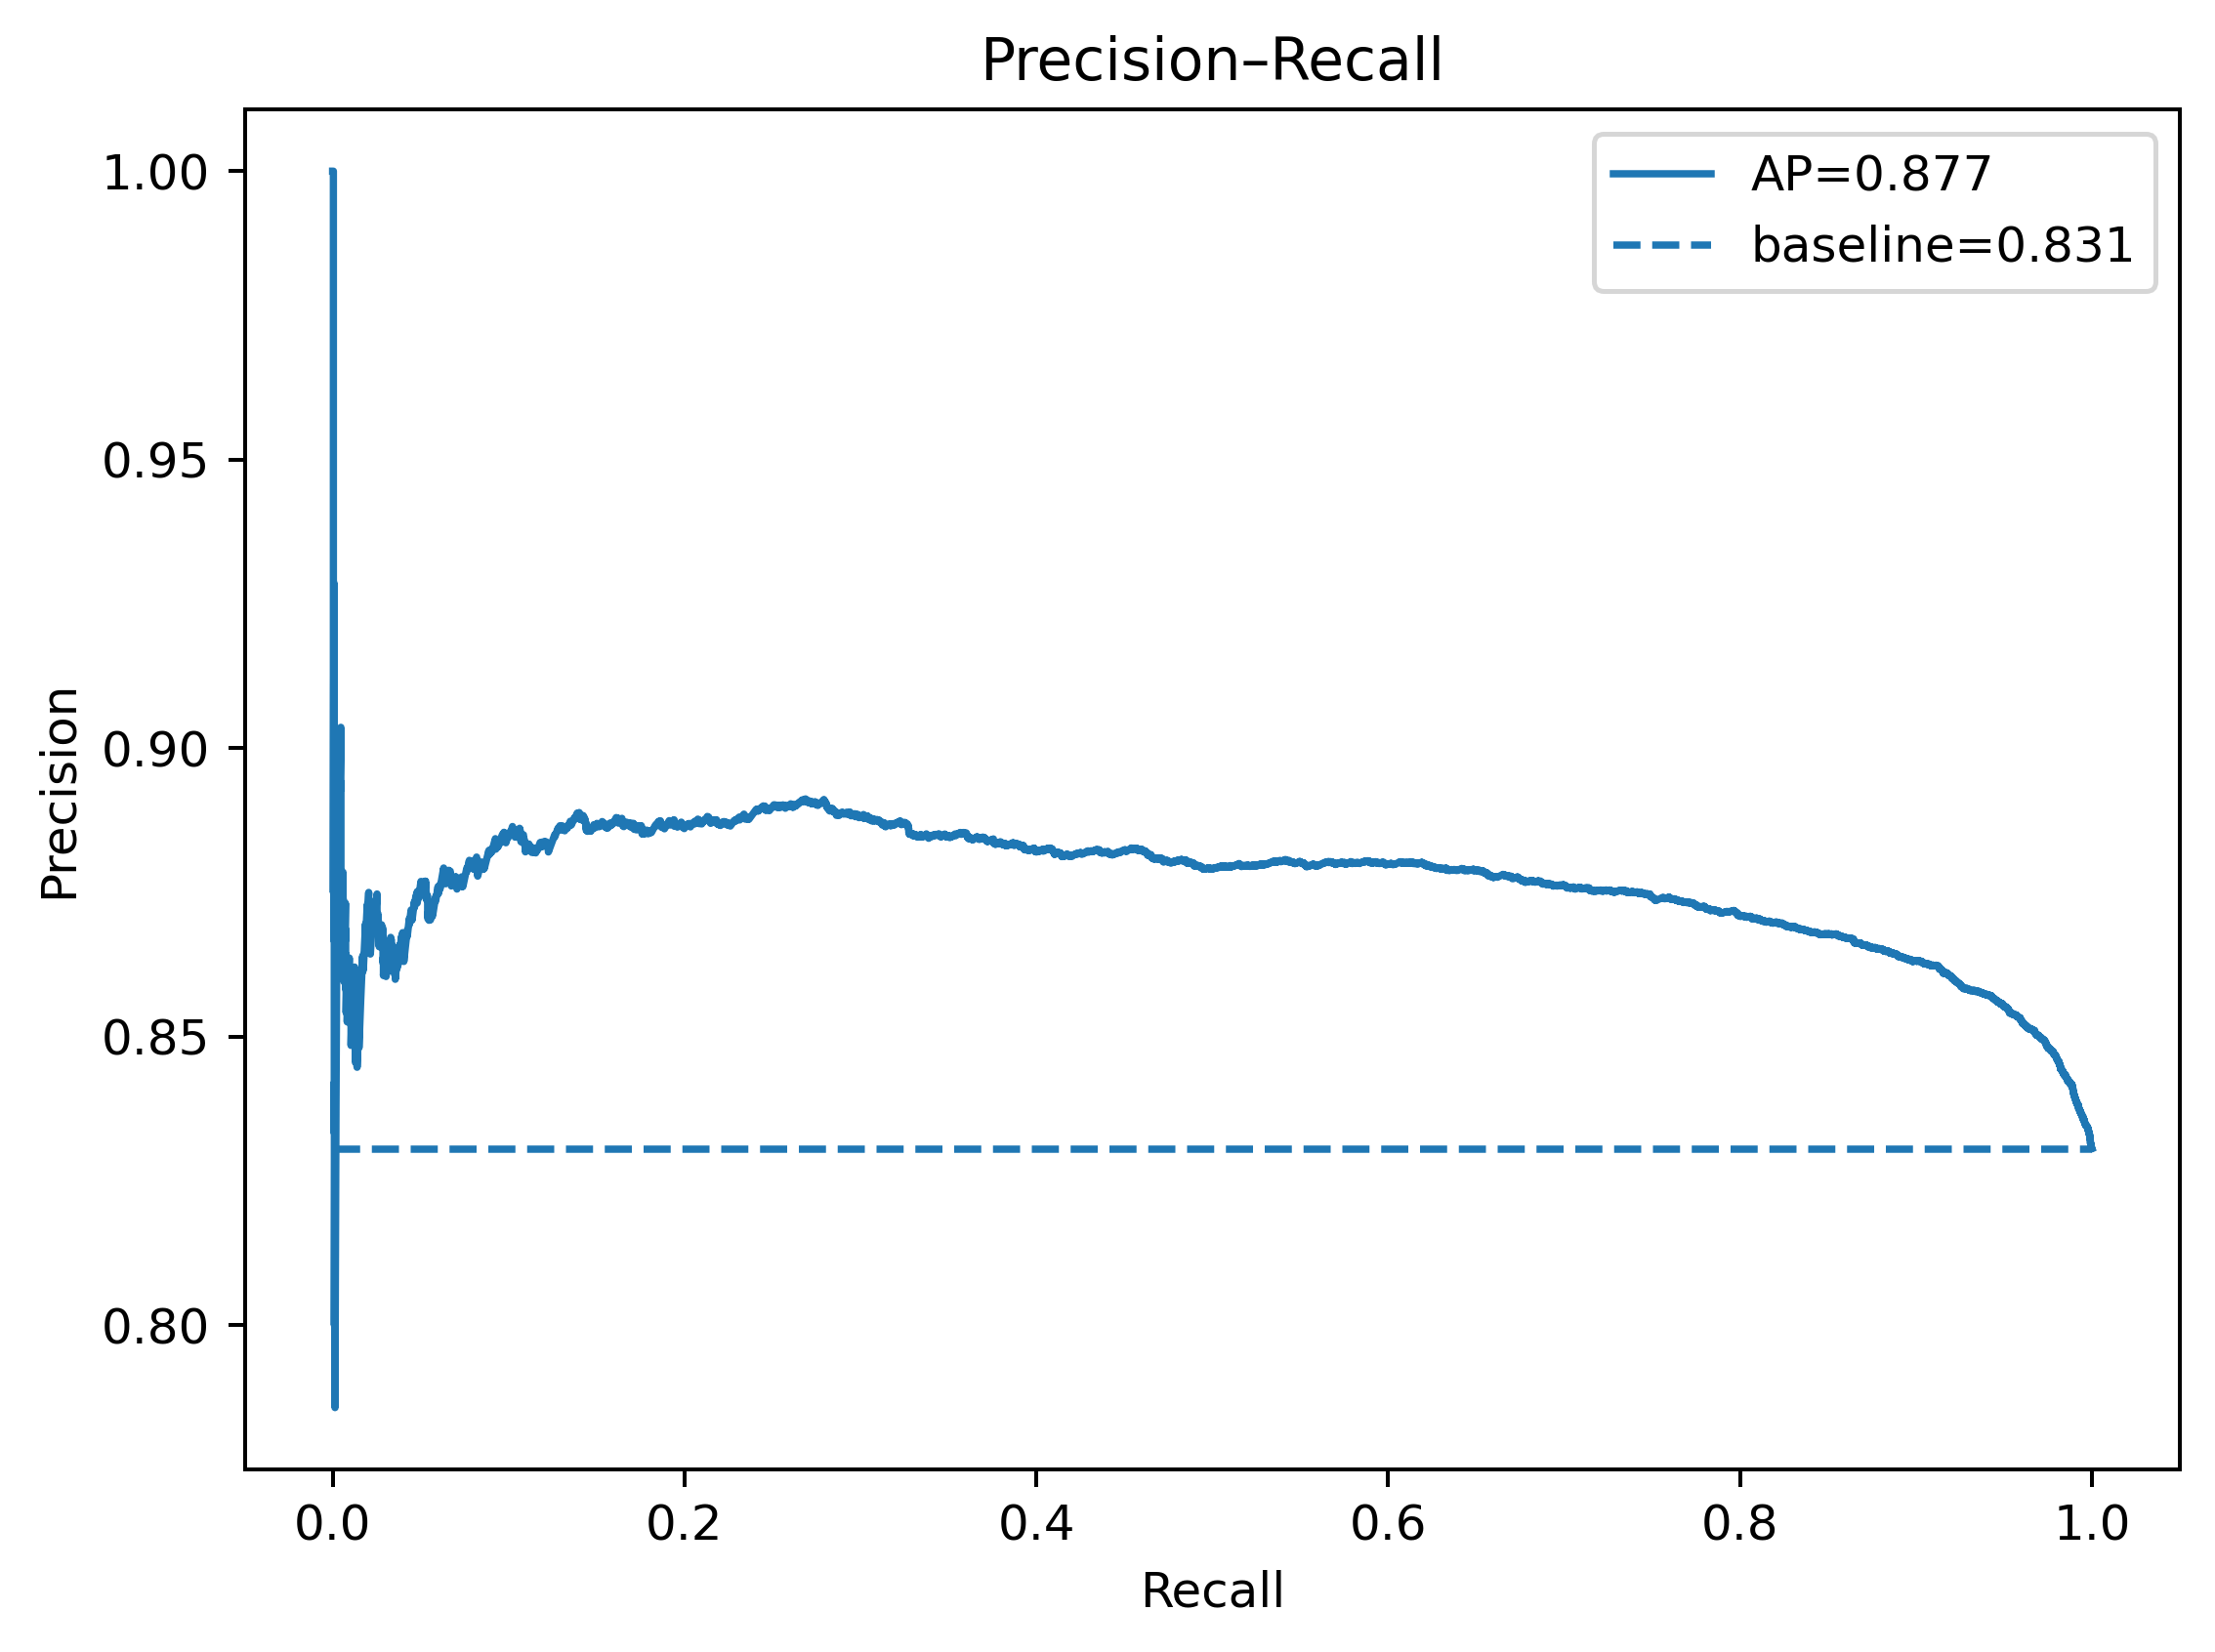

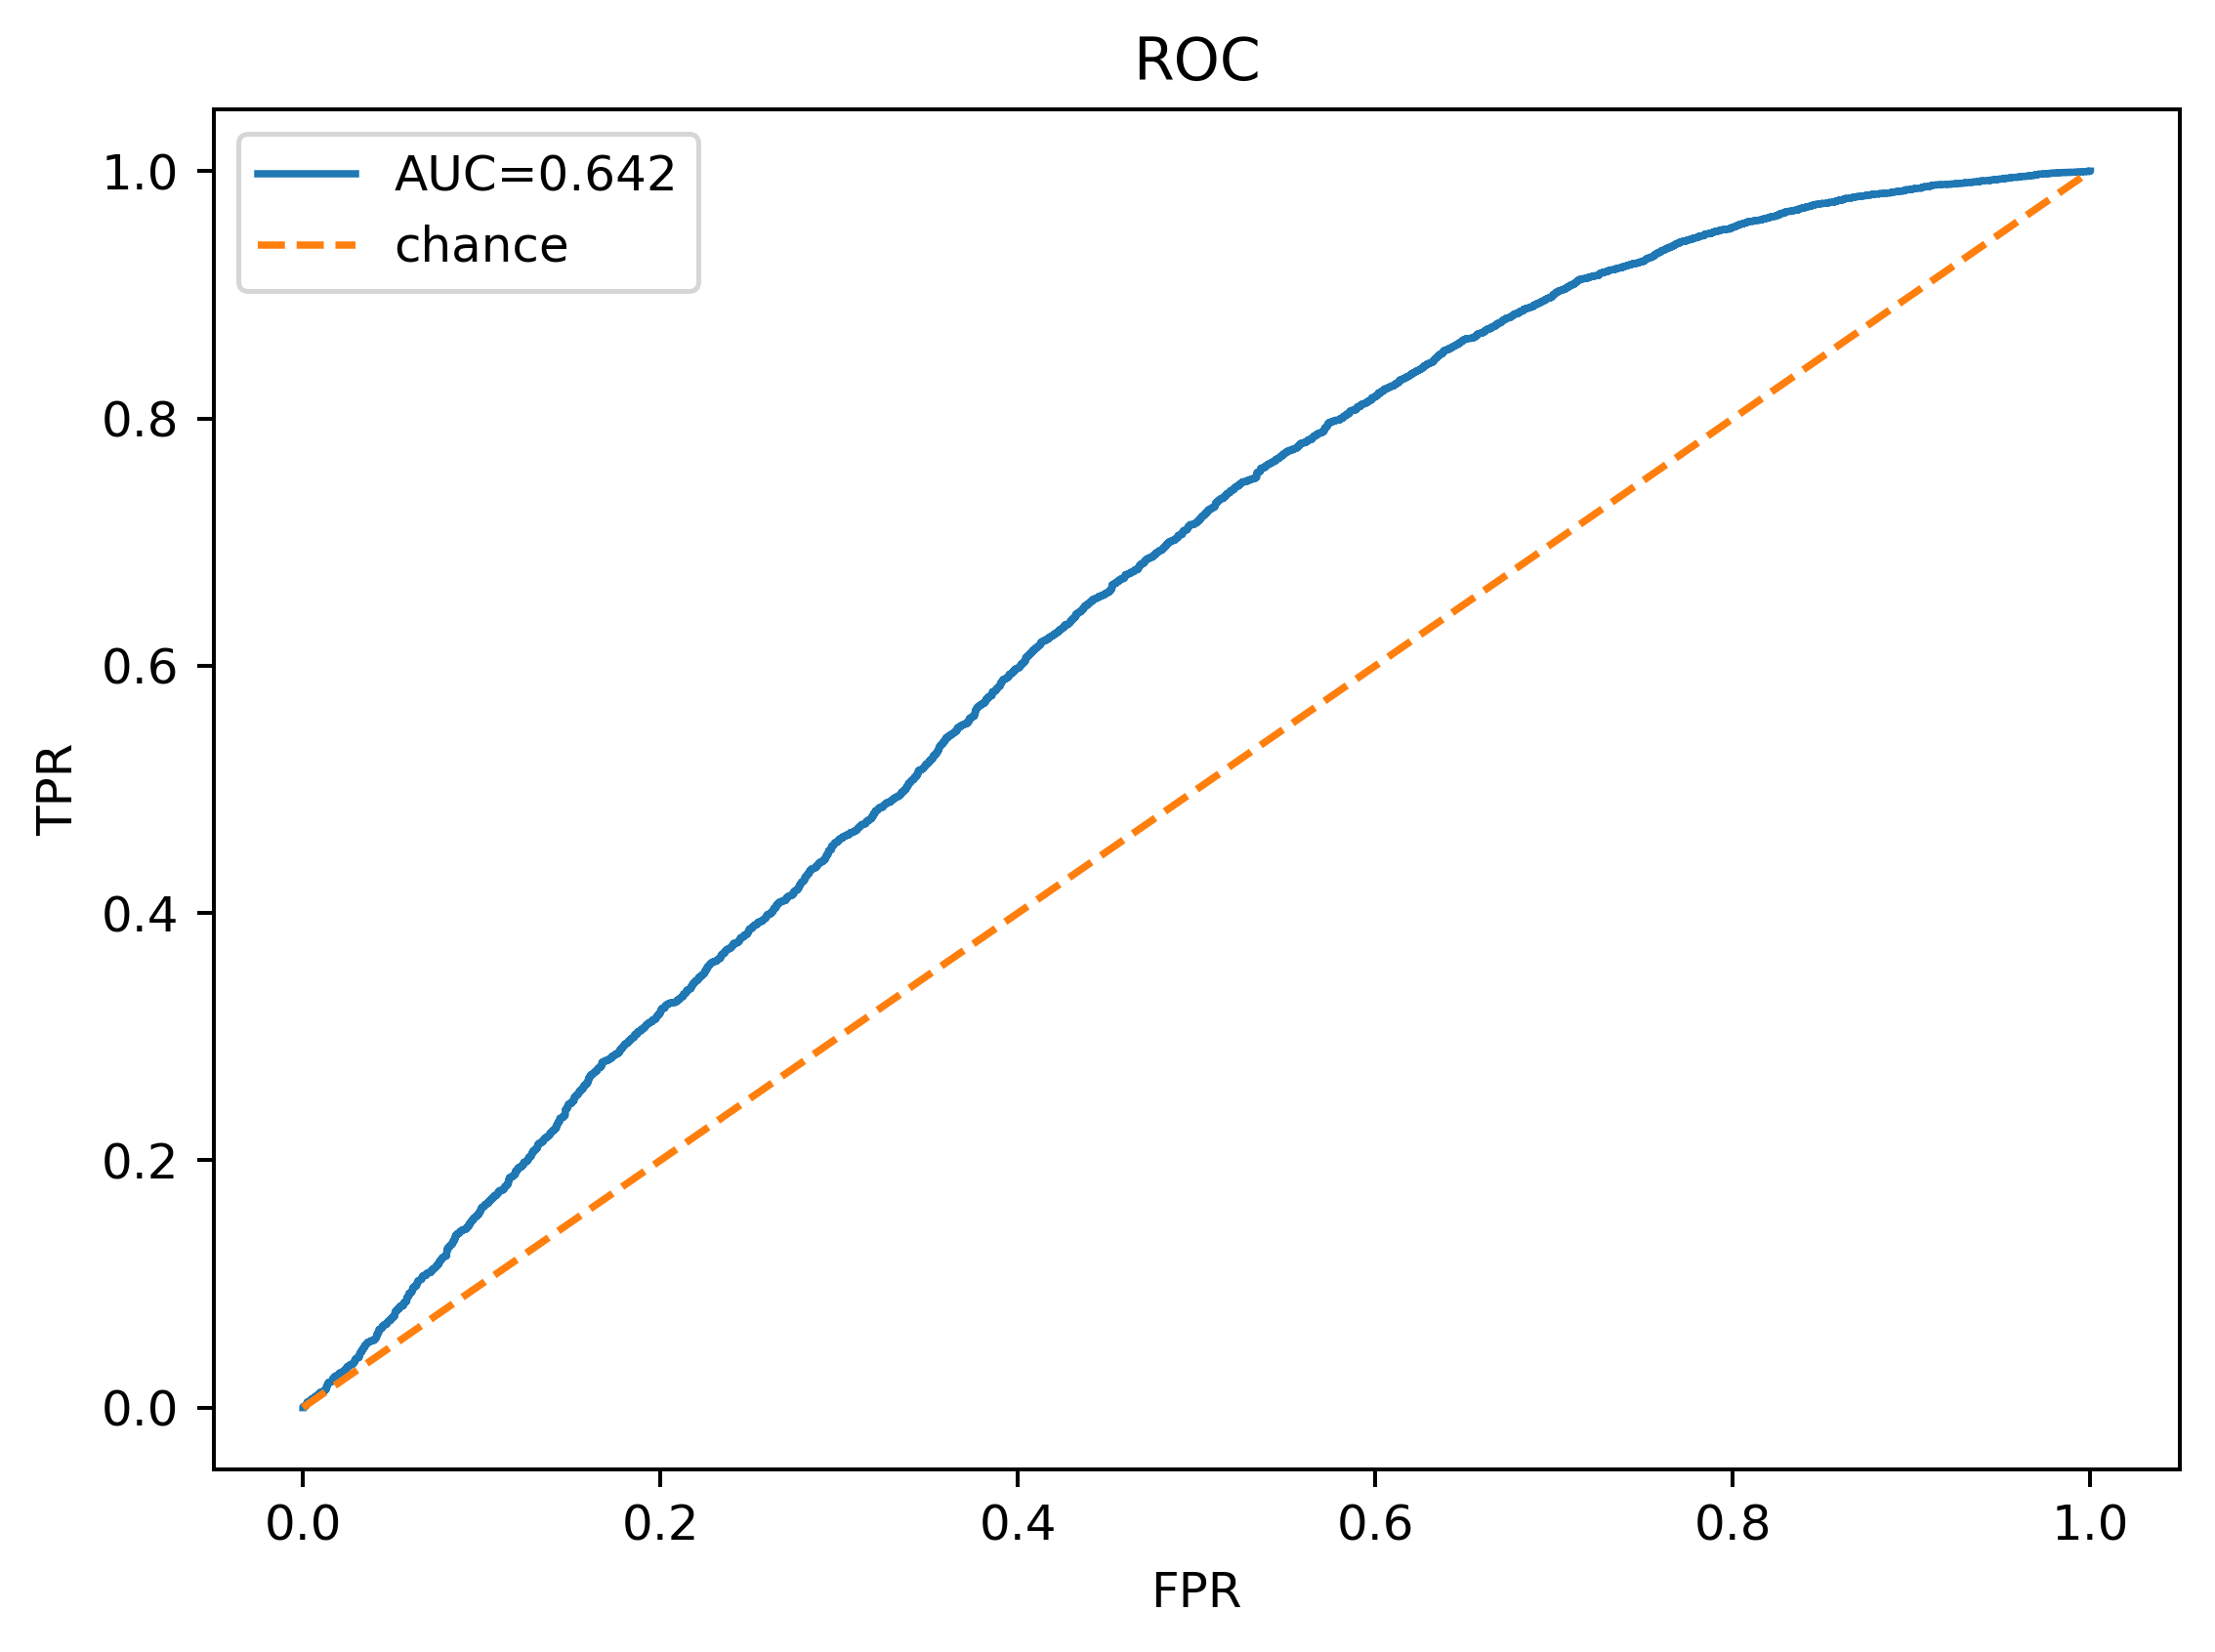

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# PR curve
p, r, _ = precision_recall_curve(yte, scores)
ap = average_precision_score(yte, scores)
base = float(np.mean(yte))

plt.figure()
plt.plot(r, p, label=f"AP={ap:.3f}")
plt.hlines(base, 0, 1, linestyles="dashed", label=f"baseline={base:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
plt.legend(); plt.show()

# ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(yte, scores)
roc = roc_auc_score(yte, scores)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={roc:.3f}")
plt.plot([0,1],[0,1], linestyle="dashed", label="chance")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC")
plt.legend(); plt.show()

#### PR curve should sit above the baseline (mean positive rate). 
#### ROC around ~0.64 is typical for soft signals.

## Confusion matrix at the chosen threshold

Inspect the confusion matrix at the F1-optimal threshold (for positive reviews) to see what we miss.

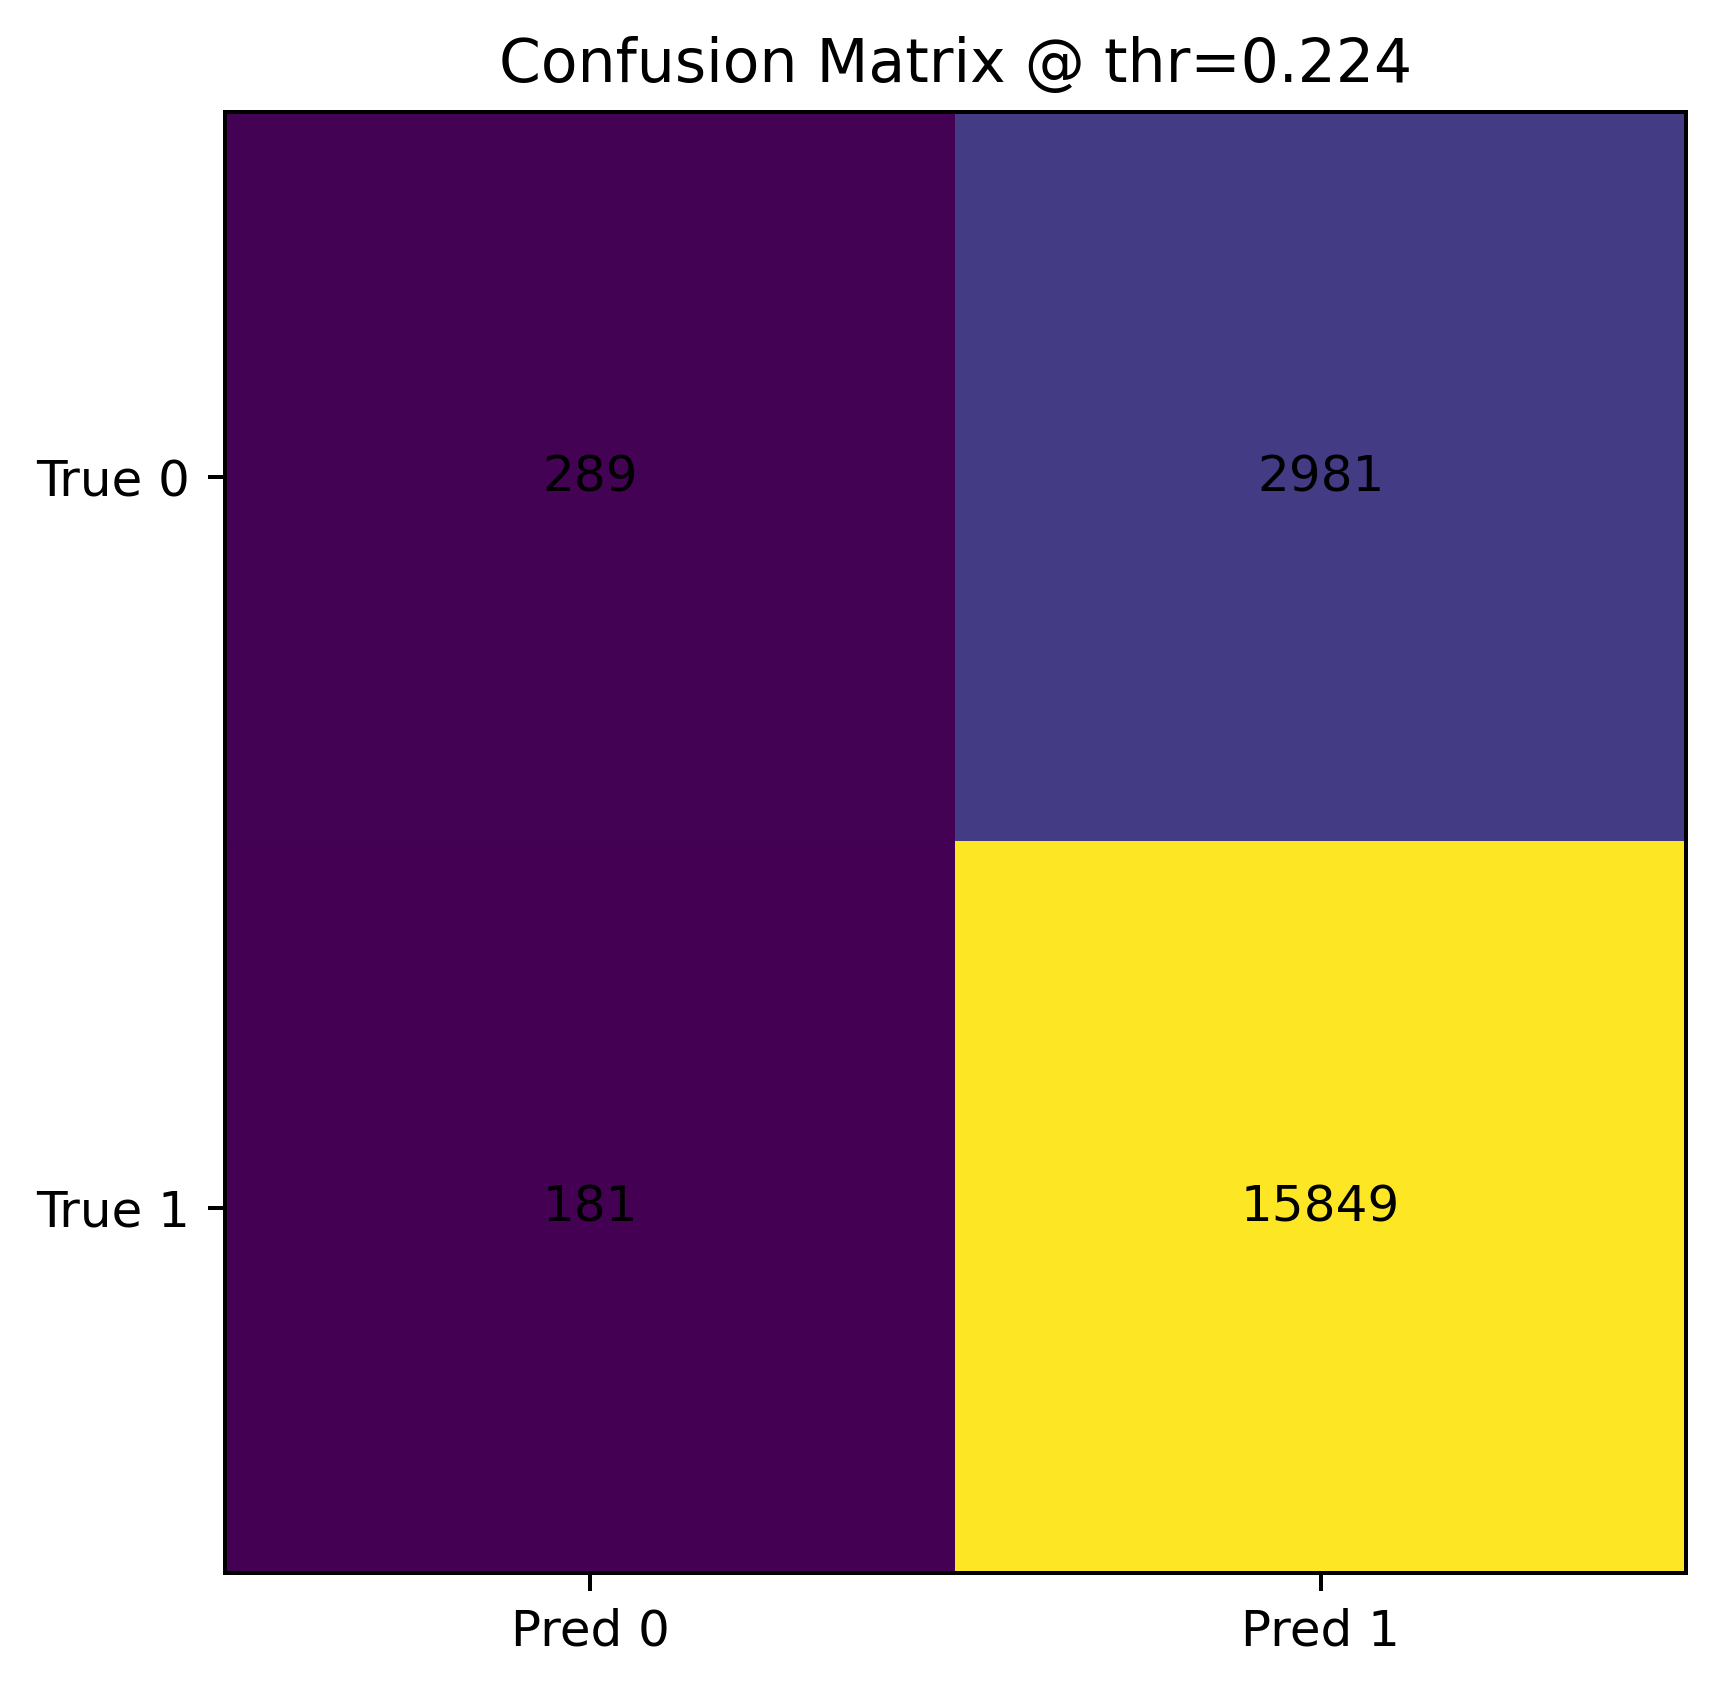

{'TN': 289, 'FP': 2981, 'FN': 181, 'TP': 15849}


In [10]:
cm = confusion_matrix(yte, yhat, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.xticks([0,1], ["Pred 0","Pred 1"])
plt.yticks([0,1], ["True 0","True 1"])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.title(f"Confusion Matrix @ thr={thr:.3f}")
plt.show()

print({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

### High TP and low FN for positives, but many FN for negative reviews (= high FP for positive reviews) at this threshold.

## Odds ratios for numeric features

Read the logistic coefficients as odds ratios (values <1 reduce odds of a positive review).

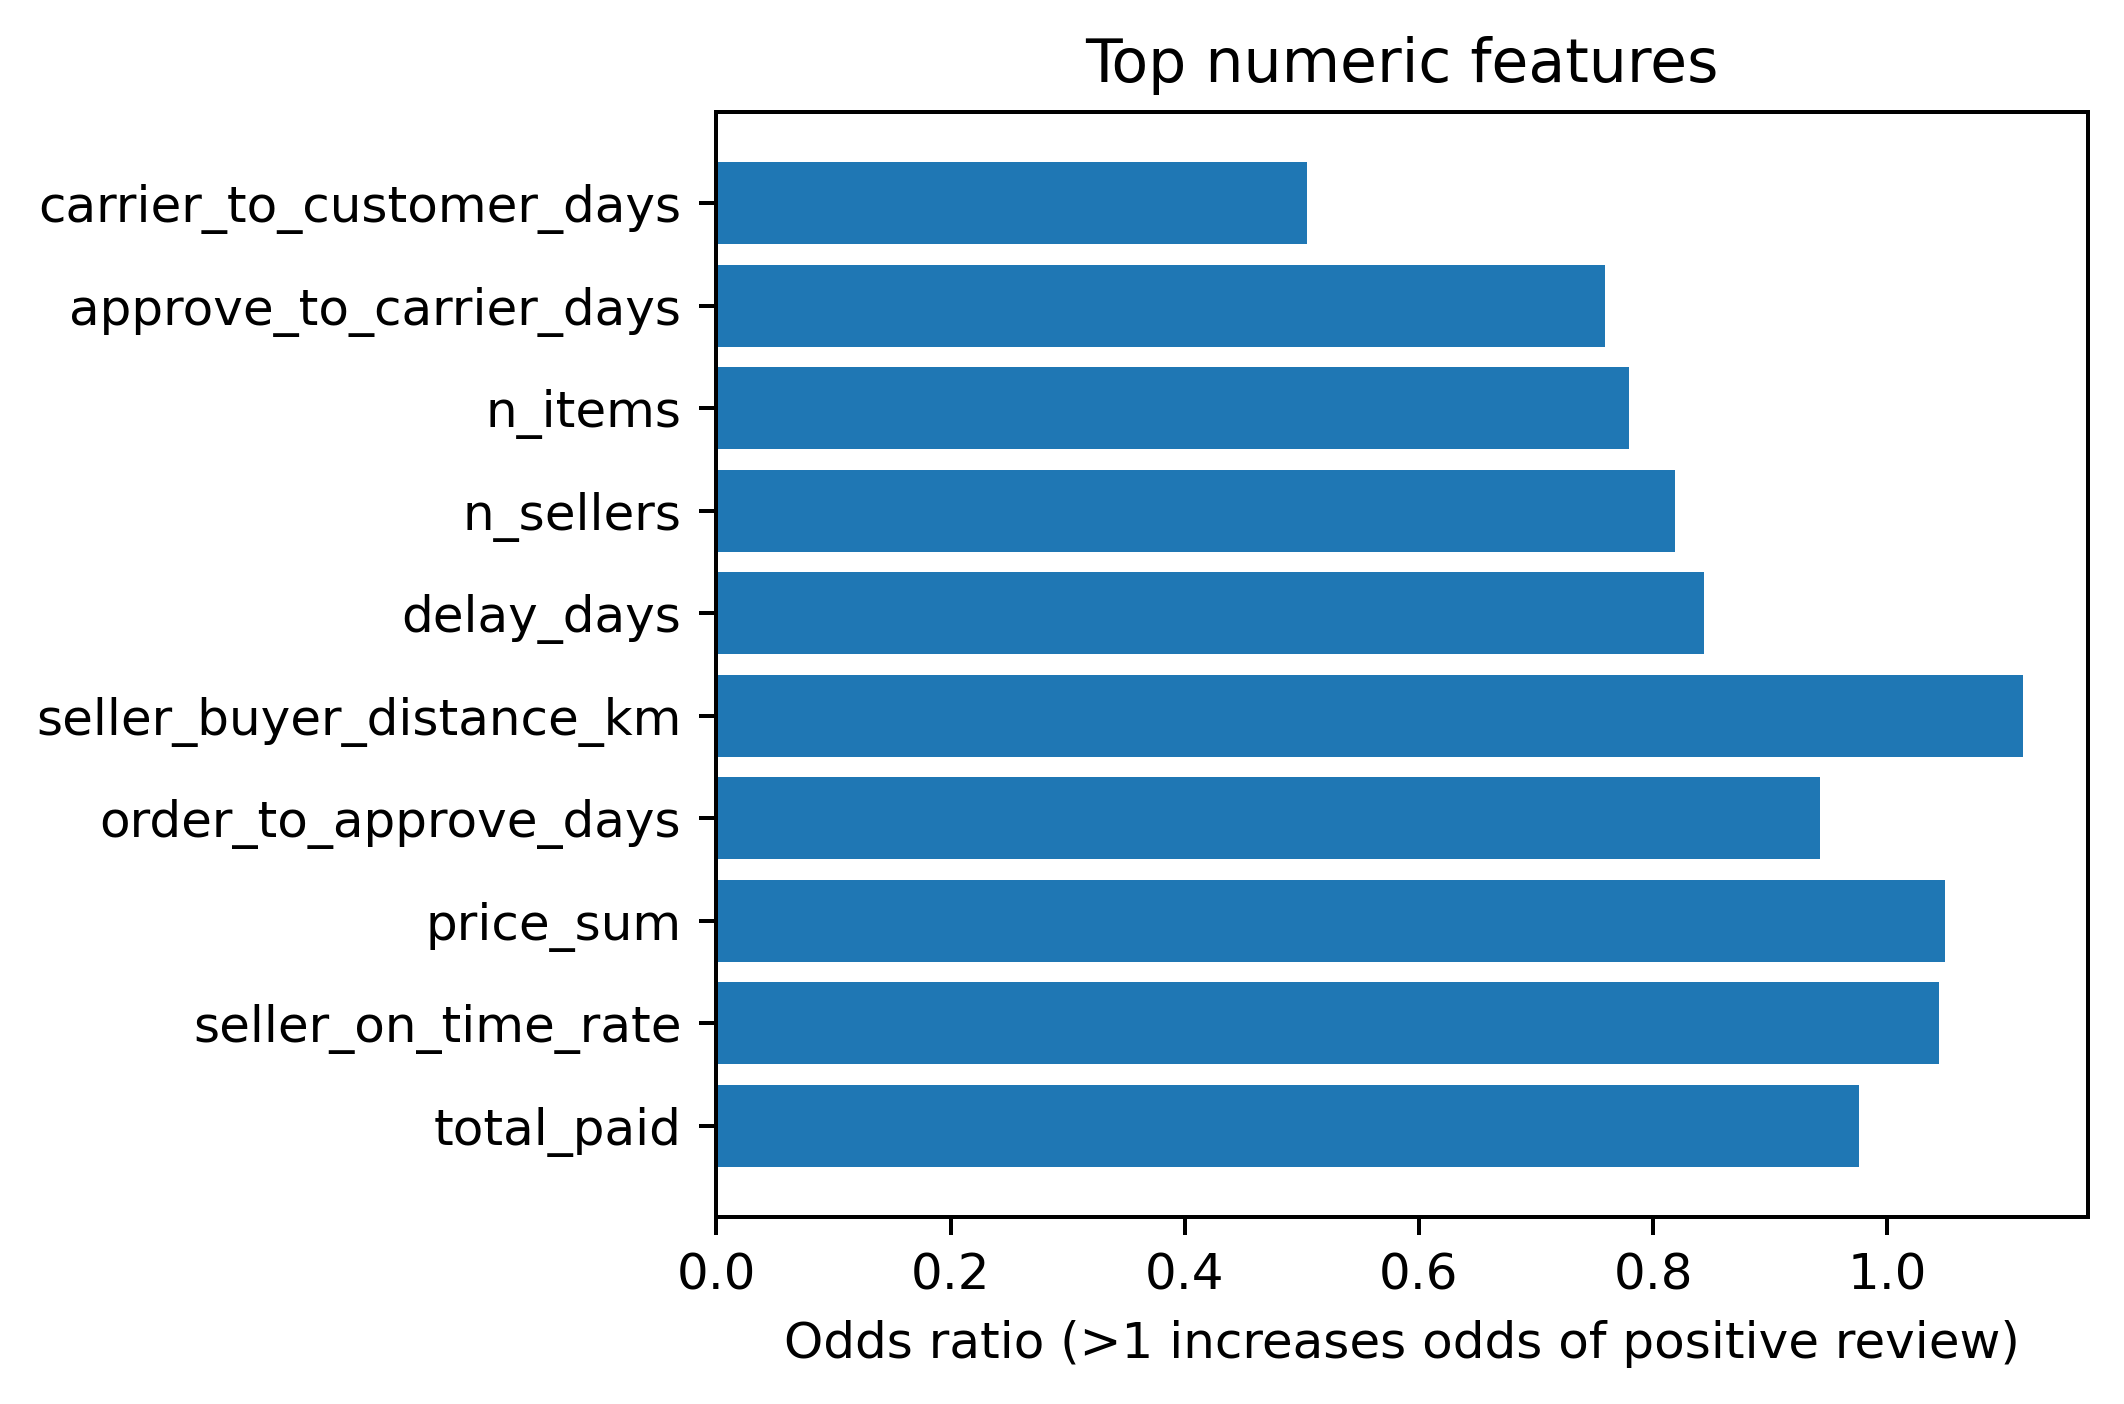

In [11]:
oh = logreg.named_steps["pre"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = oh.get_feature_names_out(cat_cols)

coef = logreg.named_steps["clf"].coef_.ravel()
odds = np.exp(coef[:len(num_cols)])  # numeric block comes first

# show top 10 by strength
order_idx = np.argsort(np.abs(np.log(odds)))[::-1][:10]
plt.figure(figsize=(6, 0.4*len(order_idx)))
plt.barh(range(len(order_idx)), odds[order_idx])
plt.yticks(range(len(order_idx)), [num_cols[i] for i in order_idx])
plt.xlabel("Odds ratio (>1 increases odds of positive review)")
plt.title("Top numeric features")
plt.gca().invert_yaxis()
plt.show()

### `delay_days` should have odds ratio < 1 (more delay → lower chance of positive review). This supports the core story.

## Alternative Target: focus on negative reviews (flip the view)

**Operationally we want to catch bad experiences.** 

So we flip the target to the negative class, compute AP for negatives, and pick a threshold for about 50% recall of negatives.

In [12]:
# negative class labels/scores from *test set*
y_neg = (yte == 0).astype(int)
neg_scores = 1.0 - scores  # higher = more likely negative

# PR for negatives
p_n, r_n, t_n = precision_recall_curve(y_neg, neg_scores)
ap_neg = average_precision_score(y_neg, neg_scores)

# choose a threshold giving ~50% recall of negatives
target_recall = 0.50
idx = np.argmin(np.abs(r_n - target_recall))
thr_neg = t_n[max(idx-1, 0)]
yhat_neg = (neg_scores >= thr_neg).astype(int)

print({"AP_neg": ap_neg, "thr_neg": float(thr_neg)})
print(classification_report(y_neg, yhat_neg, digits=3, zero_division=0))

{'AP_neg': 0.32550468848082875, 'thr_neg': 0.3925792136331311}
              precision    recall  f1-score   support

           0      0.875     0.716     0.787     16030
           1      0.264     0.500     0.346      3270

    accuracy                          0.679     19300
   macro avg      0.570     0.608     0.567     19300
weighted avg      0.772     0.679     0.713     19300



### This reframing boosts recall of negatives dramatically (as seen in PDF), so is much more useful for interventions.


##  Cumulative gain (negative class)

Show how many negatives we capture by reviewing the top x% highest-risk orders.

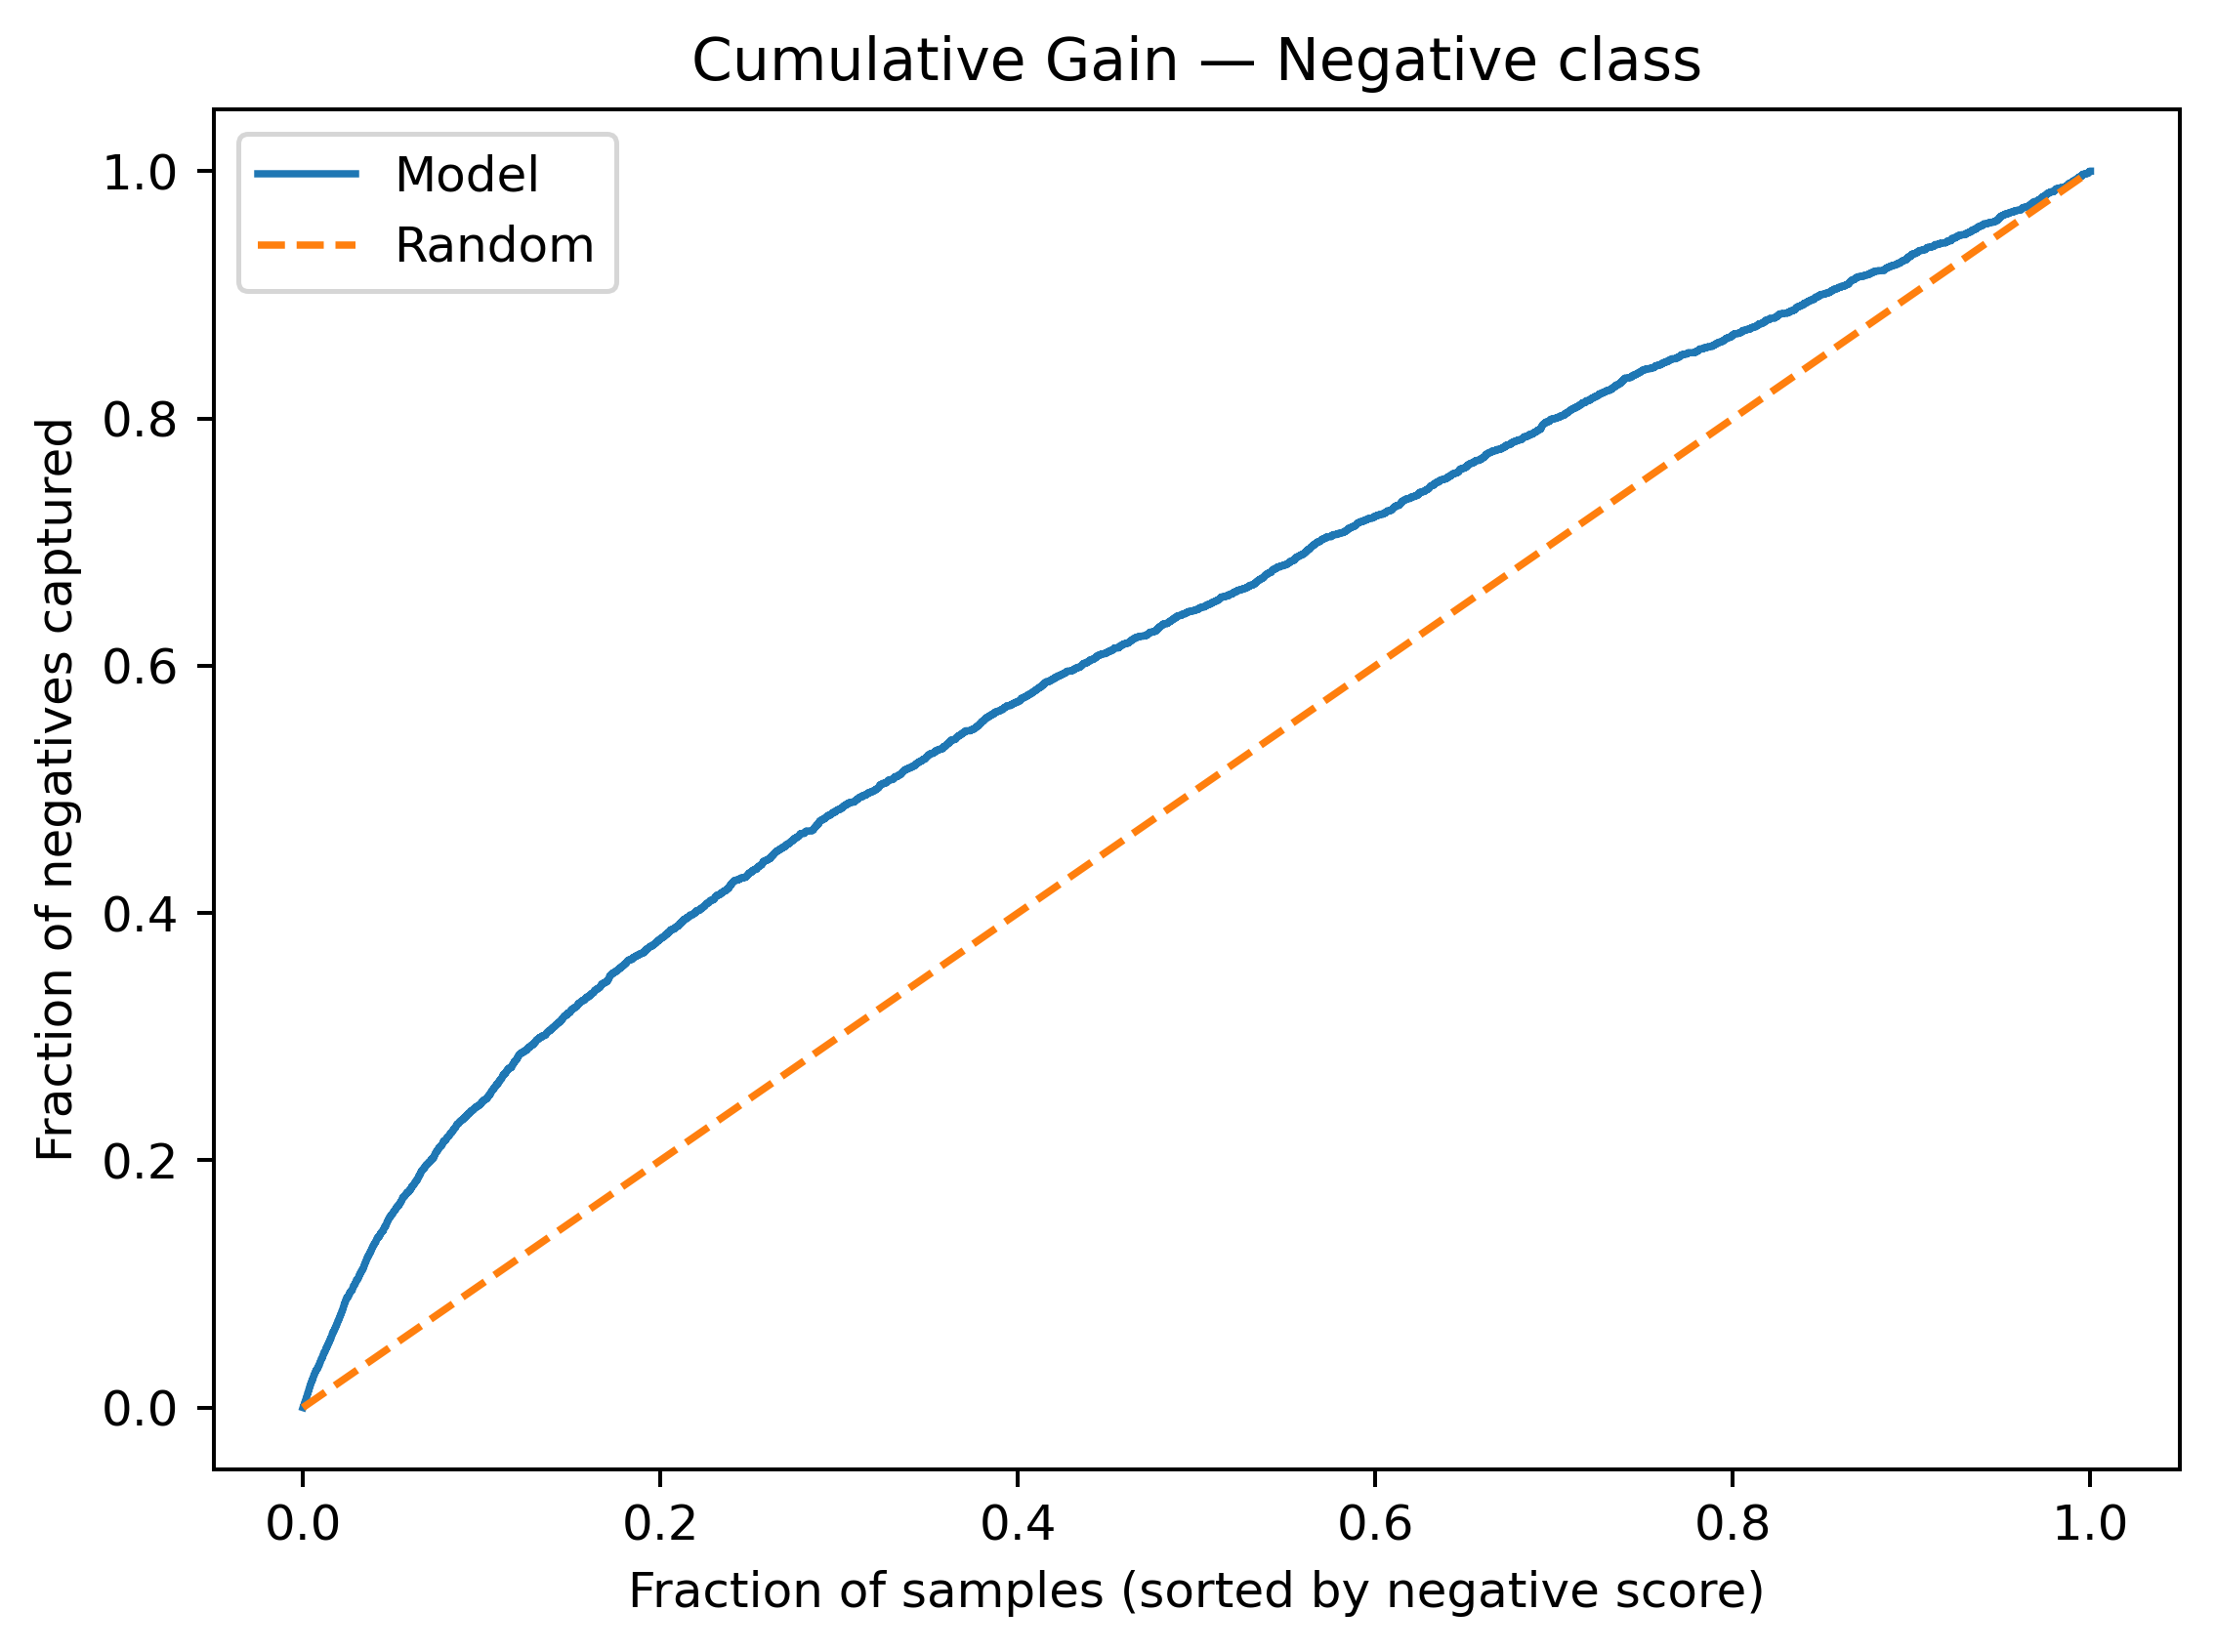

In [13]:
order_idx = np.argsort(neg_scores)[::-1]
y_sorted = y_neg[order_idx]
cum_neg = np.cumsum(y_sorted)
total_neg = max(int(cum_neg[-1]) if len(cum_neg) else 0, 1)

x = np.arange(1, len(y_sorted)+1) / len(y_sorted)
gain = cum_neg / total_neg

plt.figure()
plt.plot(x, gain, label="Model")
plt.plot([0,1],[0,1], "--", label="Random")
plt.xlabel("Fraction of samples (sorted by negative score)")
plt.ylabel("Fraction of negatives captured")
plt.title("Cumulative Gain — Negative class")
plt.legend(); plt.show()

### Curve above the diagonal shows ranking is helpful to prioritize cases likely to go poorly.

## Try a tree model (nonlinear lift)

A LightGBM model can capture interactions and sometimes improve ranking. This keeps it simple (numeric features only).

In [15]:
if HAS_LGBM:
    numeric_names = num_cols  # use numeric features to keep it simple
    lgbm = Pipeline([
        ("prep_num", SimpleImputer(strategy="median")),
        ("clf", LGBMClassifier(
            n_estimators=600, learning_rate=0.05, num_leaves=63,
            subsample=0.8, colsample_bytree=0.8,
            class_weight="balanced", random_state=RNG
        ))
    ])
    lgbm.fit(Xtr[numeric_names], ytr)
    scores_lgbm = lgbm.predict_proba(Xte[numeric_names])[:,1]

    print({
        "LGBM_PR_AUC": average_precision_score(yte, scores_lgbm),
        "LGBM_ROC_AUC": roc_auc_score(yte, scores_lgbm)
    })

[LightGBM] [Info] Number of positive: 59622, number of negative: 17579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2333
[LightGBM] [Info] Number of data points in the train set: 77201, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
{'LGBM_PR_AUC': 0.8735779504402249, 'LGBM_ROC_AUC': 0.6369847915128553}


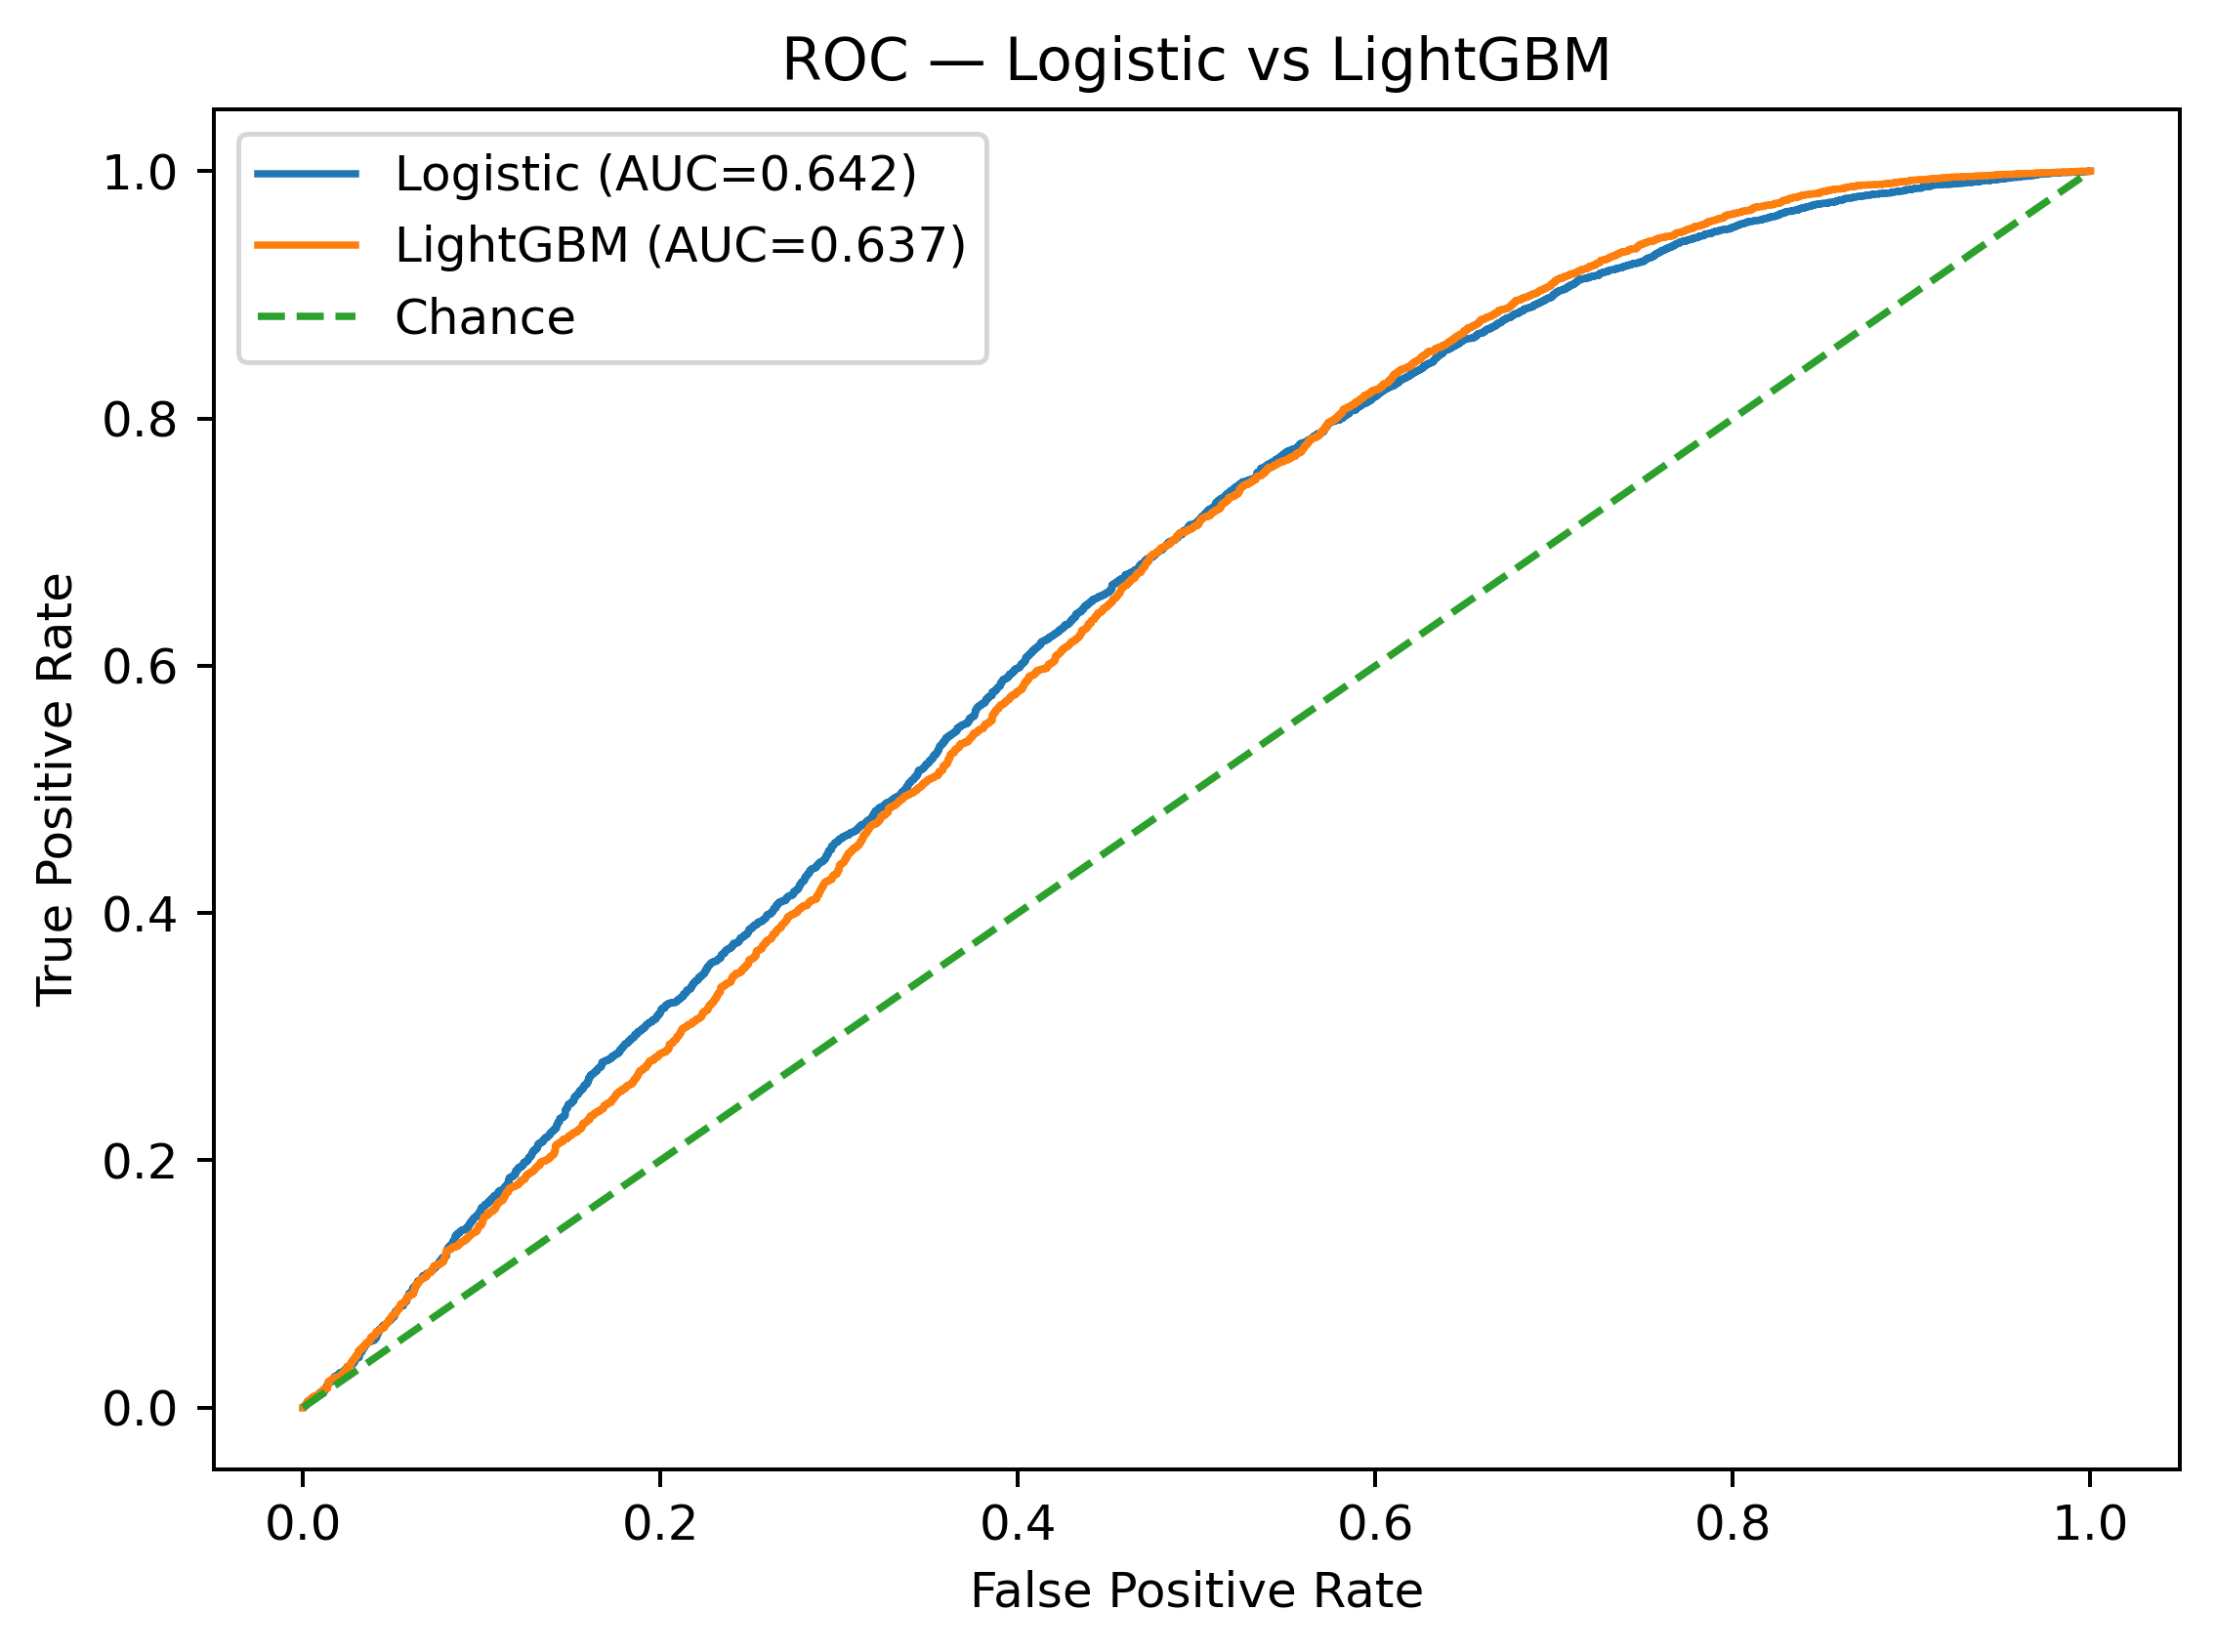

In [16]:
y = np.asarray(yte).astype(int)

# ROC for Logistic
fpr_lr, tpr_lr, _ = roc_curve(y, scores)
auc_lr = roc_auc_score(y, scores)

# ROC for LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y, scores_lgbm)
auc_lgbm = roc_auc_score(y, scores_lgbm)

plt.figure()
plt.plot(fpr_lr,   tpr_lr,   label=f"Logistic (AUC={auc_lr:.3f})")
plt.plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM (AUC={auc_lgbm:.3f})")
plt.plot([0,1], [0,1], "--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Logistic vs LightGBM")
plt.legend()
plt.show()

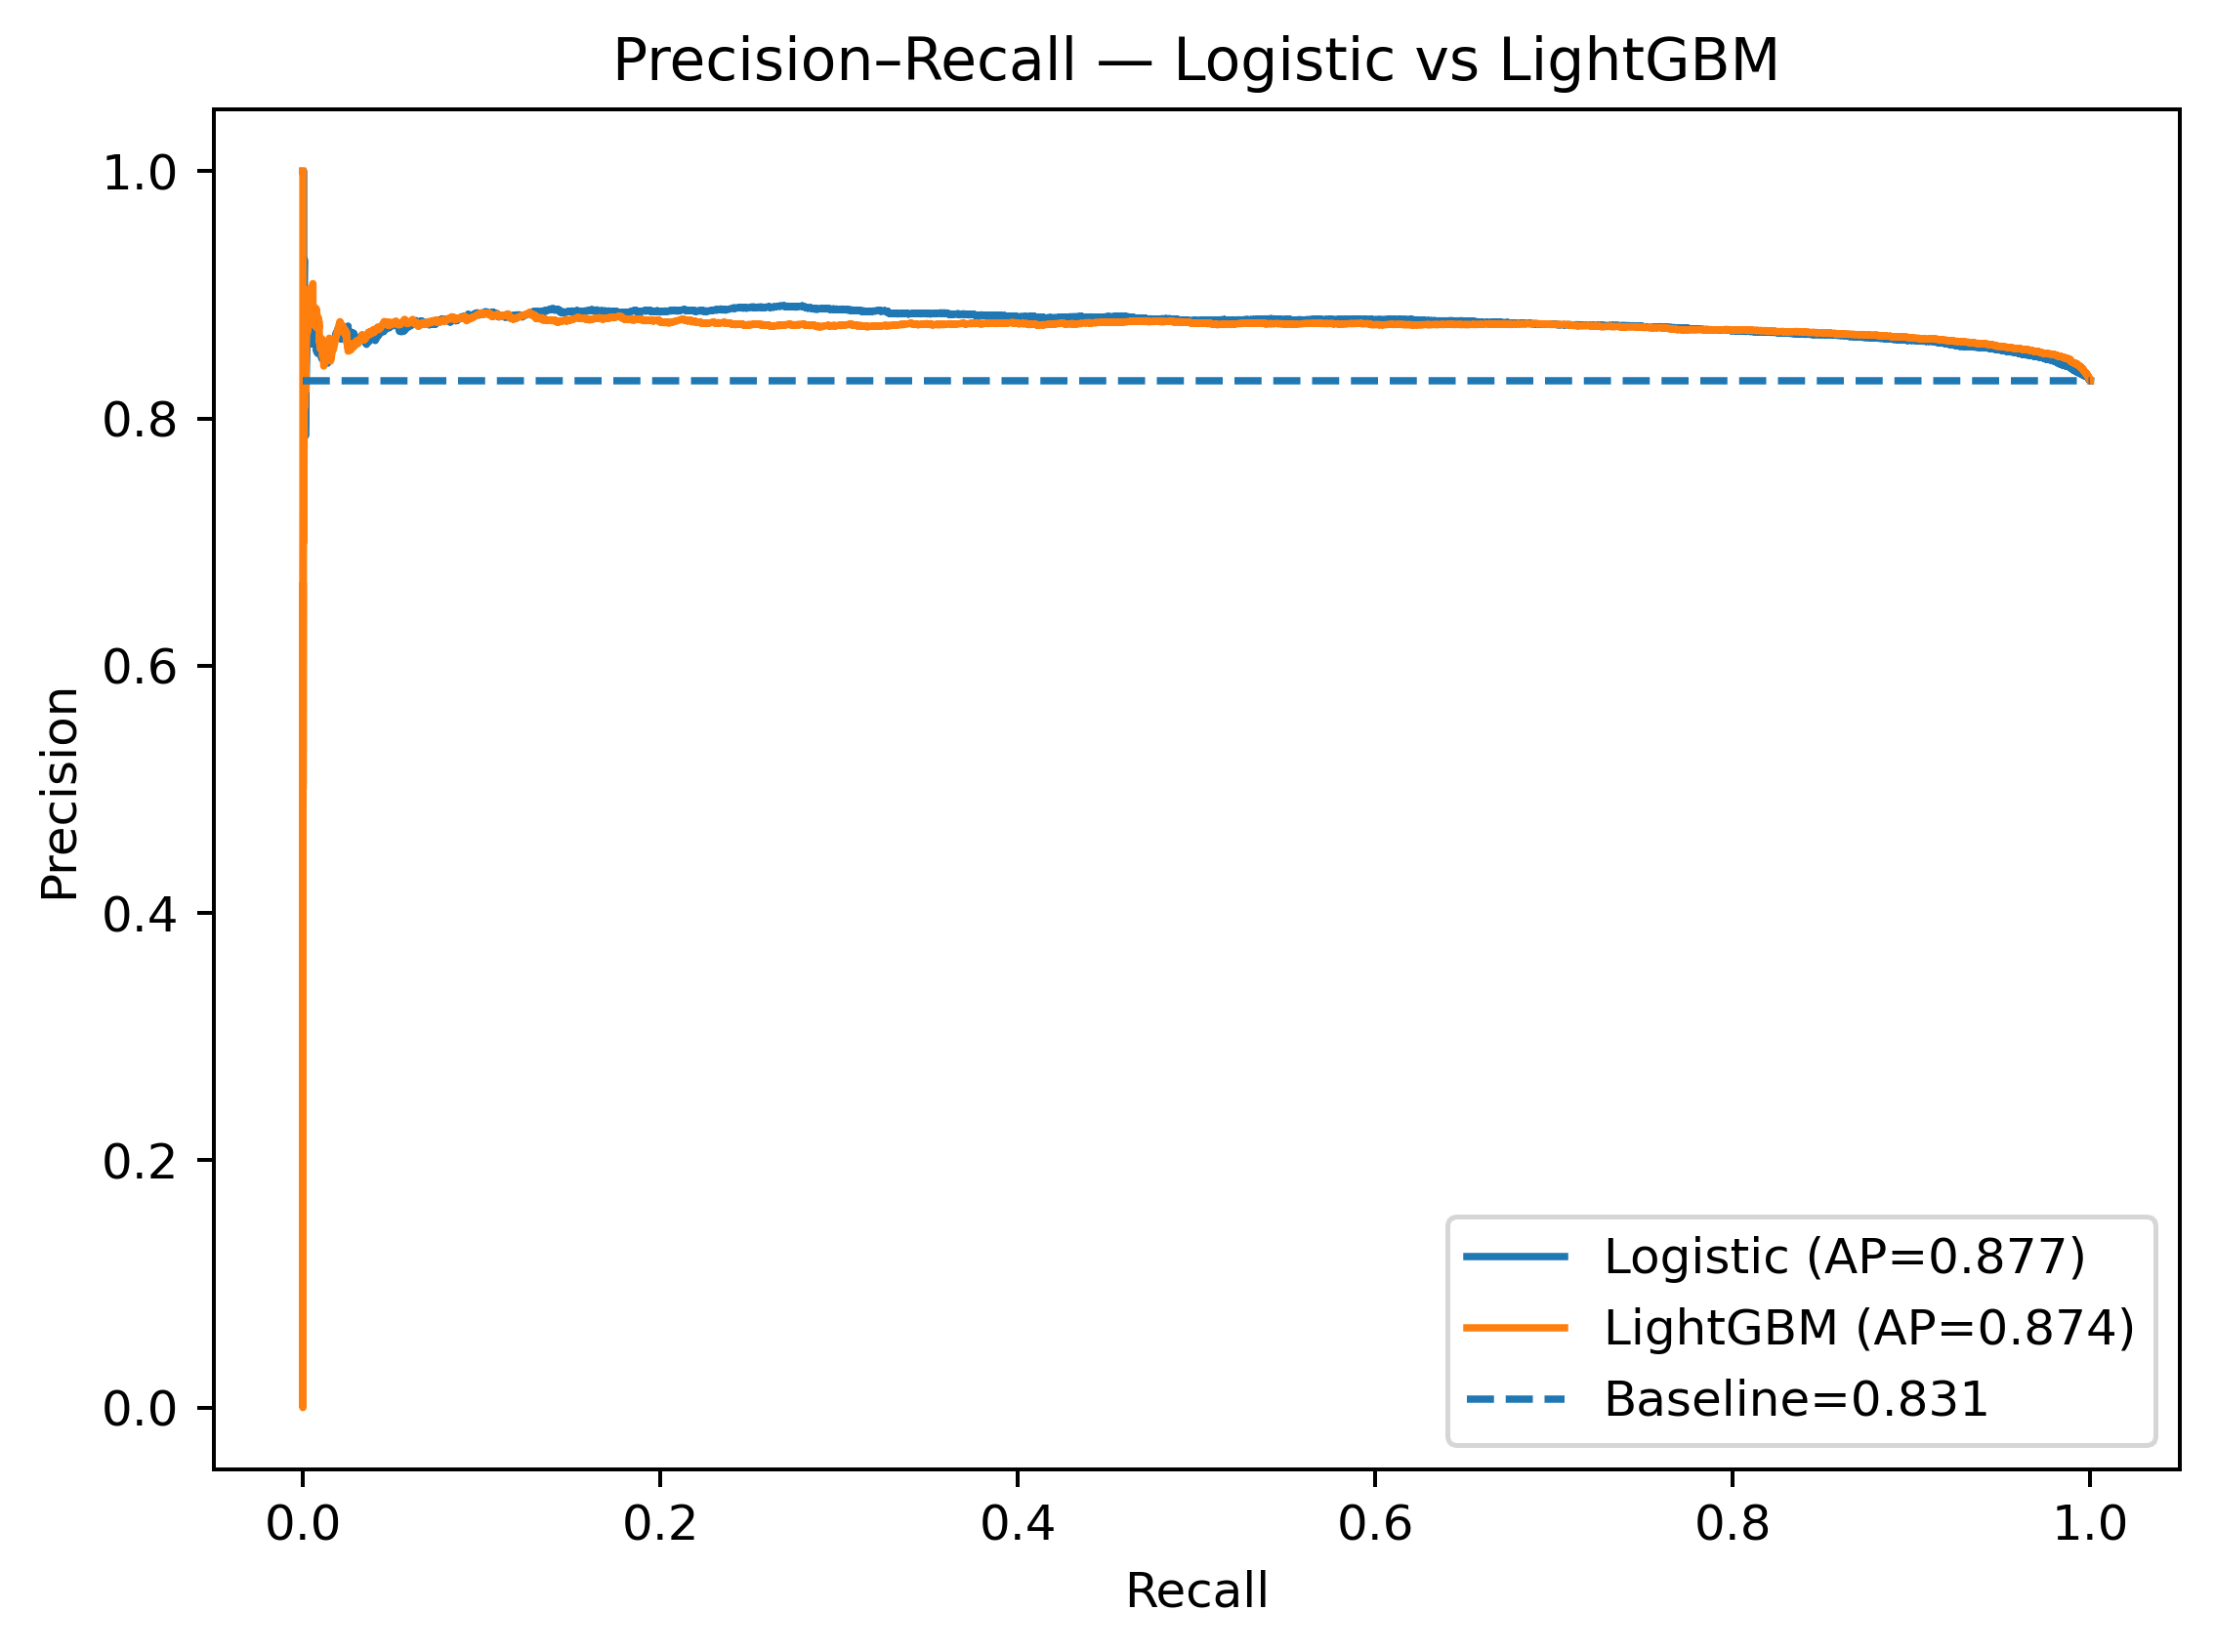

In [17]:
p1, r1, _ = precision_recall_curve(y, scores)
ap1 = average_precision_score(y, scores)

p2, r2, _ = precision_recall_curve(y, scores_lgbm)
ap2 = average_precision_score(y, scores_lgbm)

plt.figure()
plt.plot(r1, p1, label=f"Logistic (AP={ap1:.3f})")
plt.plot(r2, p2, label=f"LightGBM (AP={ap2:.3f})")
plt.hlines(y.mean(), 0, 1, linestyles="dashed", label=f"Baseline={y.mean():.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall — Logistic vs LightGBM")
plt.legend(); plt.show()

###  So far, the tree isn’t outperforming logistic.

Likely needs tuning and/or including categorical features (via one-hot in the pipeline) and trying a small hyperparameter grid (e.g., num_leaves, min_child_samples, feature_fraction, lambda_l1/l2).